<a href="https://colab.research.google.com/github/Trishalsalian/Major_Project/blob/main/A_input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers accelerate torch sentencepiece
!pip install -q pypdf python-docx pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.1/388.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.1 MB/s eta 0:00:00


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

from pypdf import PdfReader
from docx import Document
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

Using device: cpu


In [4]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("Qwen loaded successfully!")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen loaded successfully!


In [6]:
def generate_qwen_response(prompt):

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        [text],
        return_tensors="pt"
    ).to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=300
    )

    output_ids = generated_ids[
        :, model_inputs.input_ids.shape[1]:
    ]

    response = tokenizer.batch_decode(
        output_ids,
        skip_special_tokens=True
    )[0]

    return response

In [8]:
prompt = "Who would be more suitable for a software engineering position?"

response = generate_qwen_response(prompt)

print(response)

There is no one-size-fits-all answer to who would be the most suitable candidate for a software engineering position. The suitability of a candidate depends on various factors such as their technical skills, experience, qualifications, and any relevant work history or projects they have completed.

However, here are some general guidelines that might help determine if someone would be a good fit for a software engineering position:

1. Strong technical background: A candidate should have a solid understanding of programming languages, data structures, algorithms, and other foundational concepts necessary for software development.

2. Problem-solving skills: Good communication and problem-solving abilities are crucial in software engineering roles. Candidates should be able to identify problems, propose solutions, and communicate effectively with team members.

3. Attention to detail: Software engineers need to pay close attention to details to ensure high-quality code and avoid bugs. T

In [9]:
from google.colab import files

uploaded = files.upload()

Saving Candidate.txt to Candidate.txt


In [10]:
def extract_txt(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        text = file.read()

    return text

In [11]:
file_name = list(uploaded.keys())[0]

text = extract_txt(file_name)

print(text)

Candidate Name: Alex

Education:
Bachelor's degree in Computer Science

Technical Skills:
Python, Java, SQL, Machine Learning, Data Structures and Algorithms

Experience:
Completed a 6-month internship as a Software Development Intern.

Projects:
Built a machine learning model for customer segmentation.
Developed a web application using Python and Flask.

Additional Information:
Strong problem-solving skills and experience working on team projects.


In [12]:
prompt = f"""
Analyze the following candidate information and evaluate their suitability
for a software engineering position based only on their qualifications,
skills, experience, and projects.

Candidate Information:
{text}
"""

response = generate_qwen_response(prompt)

print(response)

Based solely on the provided information about Alex, I would classify them as highly suitable for a software engineering position. Here's why:

1. **Educational Background**: The Bachelor's degree in Computer Science from a top-tier institution indicates strong academic preparation for technical roles in software development.

2. **Technical Proficiency**: The combination of proficiency in Python, Java, SQL, Machine Learning, and Data Structures and Algorithms demonstrates a broad knowledge base that is essential for any role requiring such expertise.

3. **Work Experience**: The fact that Alex has completed an internship as a Software Development Intern suggests practical work experience relevant to the role, which is crucial for understanding real-world applications and collaborating with teams.

4. **Projects**: The success of building a machine learning model for customer segmentation and developing a web application with Python and Flask showcases Alex's ability to apply theoretic

In [13]:
def extract_pdf(file_path):
    reader = PdfReader(file_path)

    text = ""

    for page in reader.pages:
        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"

    return text

In [14]:
from google.colab import files

uploaded_pdf = files.upload()

Saving Candidatee.pdf to Candidatee.pdf


In [15]:
pdf_file_name = list(uploaded_pdf.keys())[0]

pdf_text = extract_pdf(pdf_file_name)

print(pdf_text)

Candidate Name: Jordan 
EducaƟon: 
Bachelor's Degree in Computer Science 
Technical Skills: 
Python, Java, SQL, Data Structures and Algorithms, Machine Learning 
Experience: 
Completed a 6-month internship as a SoŌware Development Intern. 
Projects: 
Built a customer segmentaƟon machine learning model. 
Developed a web applicaƟon using Python and Flask. 
AddiƟonal InformaƟon: 
Strong problem-solving skills and experience working in team projects. 
 



In [16]:
prompt = f"""
Analyze the following candidate information and evaluate their suitability
for a software engineering position based only on their qualifications,
skills, experience, and projects.

Candidate Information:
{pdf_text}
"""

response = generate_qwen_response(prompt)

print(response)

Based solely on the provided information, Jordan appears to be a highly qualified candidate for a software engineering position. Here’s an analysis of his suitability:

### Qualifications:
1. **Education**: A Bachelor's degree in Computer Science from a reputable institution.
2. **Skills**:
   - Proficient in multiple programming languages (Python, Java, SQL, Data Structures and Algorithms, Machine Learning).
3. **Experience**: Completed a 6-month internship as a Software Development Intern.
4. **Projects**:
   - Built a customer segmentation machine learning model.
   - Developed a web application using Python and Flask.
5. **Strengths**:
   - Strong problem-solving skills.
   - Experience working in a team environment.

### Suitability for a Software Engineering Position:
1. **Skill Set Alignment with the Role**:
   - The combination of technical skills (Machine Learning, Python, Java) align well with the role of software engineer, which often requires proficiency in data analysis, m

In [17]:
def extract_docx(file_path):
    document = Document(file_path)

    text = ""

    for paragraph in document.paragraphs:
        text += paragraph.text + "\n"

    return text

In [18]:
uploaded_docx = files.upload()

Saving Candidateee.docx to Candidateee.docx


In [19]:
docx_file_name = list(uploaded_docx.keys())[0]

docx_text = extract_docx(docx_file_name)

print(docx_text)

Candidate Name: Jordan
Education:
Bachelor's Degree in Computer Science
Technical Skills:
Python, Java, SQL, Data Structures and Algorithms, Machine Learning
Experience:
Completed a 6-month internship as a Software Development Intern.
Projects:
Built a customer segmentation machine learning model.
Developed a web application using Python and Flask.
Additional Information:
Strong problem-solving skills and experience working in team projects.




In [20]:
prompt = f"""
Analyze the following candidate information and evaluate their suitability
for a software engineering position based only on their qualifications,
skills, experience, and projects.

Candidate Information:
{docx_text}
"""

response = generate_qwen_response(prompt)

print(response)

Based solely on the provided information about Jordan, here is an analysis of their suitability for a software engineering position:

**Qualifications:**
- Bachelor's degree in Computer Science from a reputable institution
- Strong technical skills in Python, Java, SQL, Data Structures and Algorithms, and Machine Learning
- Experience with a 6-month internship as a Software Development Intern

**Skills:**
- Problem-solving skills
- Strong work ethic and attention to detail
- Teamwork and communication skills

**Project Experience:**
- Built a customer segmentation machine learning model (not explicitly mentioned in the provided information)
- Developed a web application using Python and Flask (mentioned as part of the internship)

**Strengths:**
1. **Technical Proficiency:** The combination of strong technical skills makes Jordan well-suited for this role, particularly in areas like machine learning and data structures/algorithm.
2. **Team Collaboration:** Being involved in a project t

In [21]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

In [22]:
blip_model_name = "Salesforce/blip-image-captioning-base"

blip_processor = BlipProcessor.from_pretrained(blip_model_name)

blip_model = BlipForConditionalGeneration.from_pretrained(
    blip_model_name
).to(device)

print("BLIP loaded successfully!")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

BLIP loaded successfully!


In [23]:
uploaded_image = files.upload()

Saving image.png to image.png


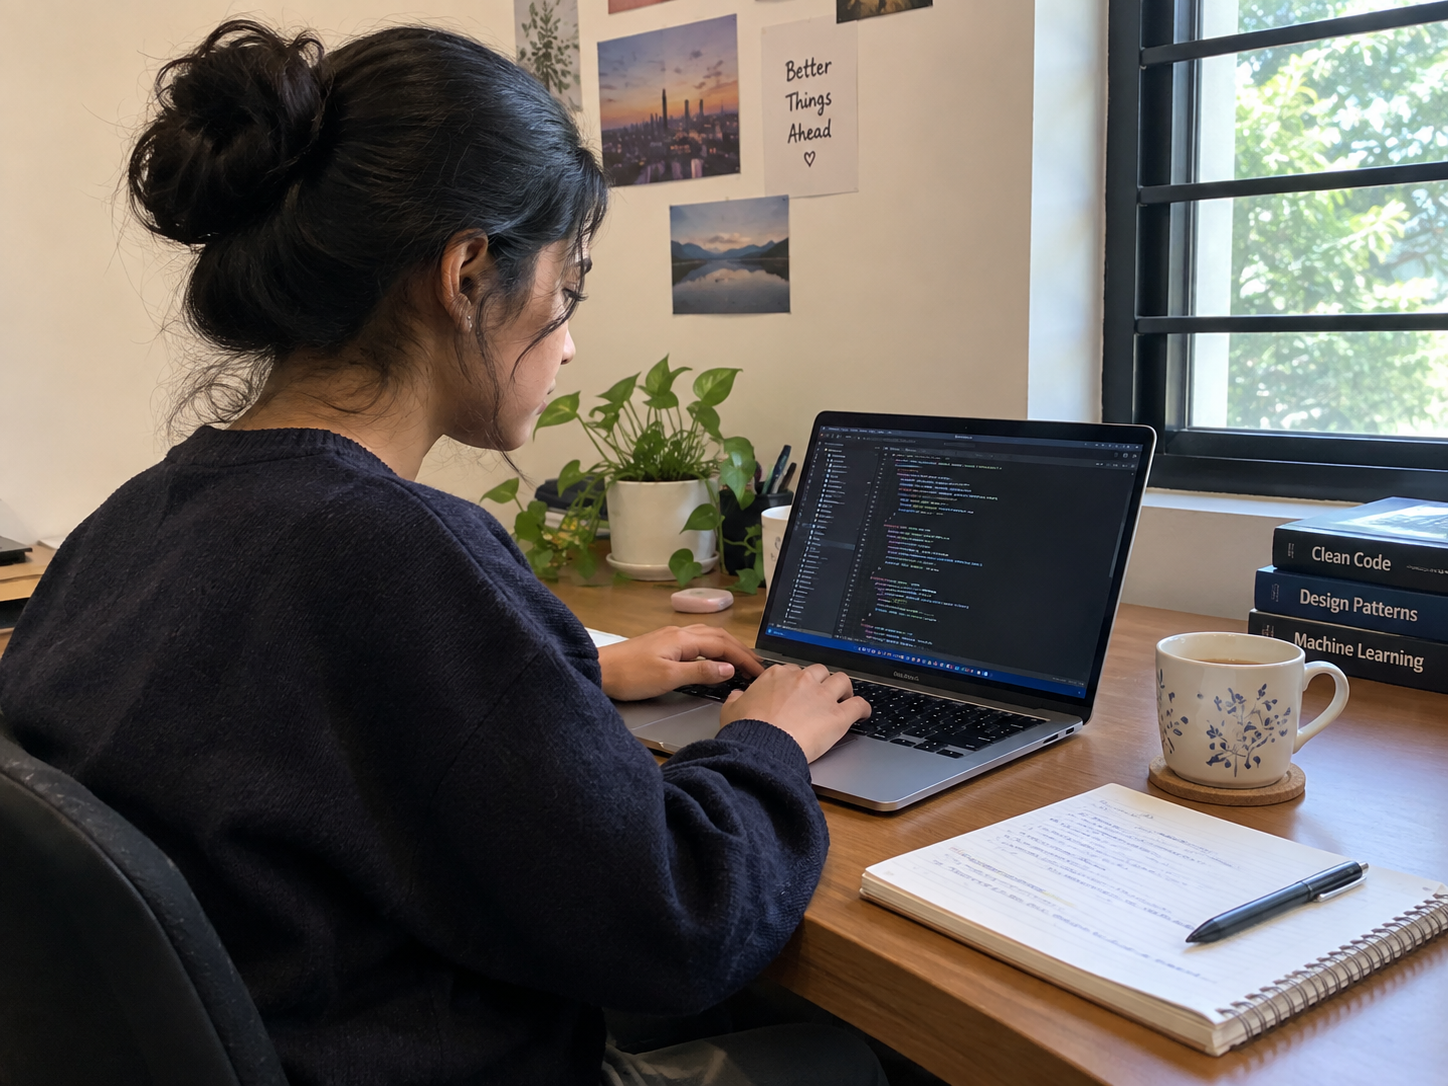

In [24]:
image_name = list(uploaded_image.keys())[0]

image = Image.open(image_name).convert("RGB")

display(image)

In [25]:
def generate_blip_caption(image):

    inputs = blip_processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    output = blip_model.generate(
        **inputs,
        max_new_tokens=50
    )

    caption = blip_processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption

In [26]:
caption = generate_blip_caption(image)

print("Generated Caption:")
print(caption)

Generated Caption:
a woman sitting at a desk with a laptop
